# Transfer Learning on Cats vs Dogs with HuggingFace ViT

## Feature Extraction Solution with Cell Outputs

### CIML Summer Institute
### UC San Diego

This notebook uses Hugging Face Transformers to solve an image classification problem with a pre-trained Vision Transformer (ViT).
We load the model with `AutoModelForImageClassification.from_pretrained(...)`, which gives us a backbone plus a classifier head, and then we freeze most of the backbone so only the final layer learns the cats-vs-dogs decision boundary.

That type of transfer learning is referred to as feature extraction. It is useful because the model can reuse visual features learned on a large pretraining corpus, so training is faster and usually less data-hungry than fitting everything from scratch.

For the image inputs, `ViTImageProcessor.from_pretrained(...)` gives us the preprocessing recipe associated with the checkpoint, including resizing and normalization. Matching the processor to the checkpoint matters because the backbone expects inputs in the same format it saw during pretraining.

Base model:
https://huggingface.co/google/vit-base-patch16-224-in21k

`AutoModelForImageClassification` docs:
https://huggingface.co/docs/transformers/en/model_doc/auto#transformers.AutoModelForImageClassification

In the finetuning notebook, you will see the same Hugging Face workflow, but with data augmentation and a different freezing strategy so more of the backbone can adapt to the new task.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# HuggingFace imports
from datasets import load_dataset
from transformers import DefaultDataCollator
from transformers import AutoModelForImageClassification
from transformers import TrainingArguments, Trainer
from transformers import pipeline
from transformers import EarlyStoppingCallback

# Evaluation
import evaluate
from sklearn.metrics import classification_report

plt.rcParams["figure.facecolor"] = "white"

## Define Parameters

In [2]:
# Input shape/statistics expected by ViT family checkpoints.
IMAGE_DIM = 224
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

# Core training hyperparameters for linear probing.
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 3
N_GPUS = torch.cuda.device_count()
N_CPUS = int(os.environ.get("SLURM_CPUS_ON_NODE", os.cpu_count()))

seed = 42

# Data location
DATA_DIR = os.environ.get("CIML26_DATA_DIR") + "/catsVsDogs"

# Where checkpoints and logs are written.
OUTPUT_DIR = "vit_cats_dogs_model/feature_extraction"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device} with {N_GPUS} GPUs and {N_CPUS} CPUs.")

Using device cuda with 1 GPUs and 4 CPUs.


In [3]:
!jupyter --version
print (torch.__version__)
!python --version

# TODO:  Use linux shell command nvidia-smi to see GPU device.  
==> YOUR CODE HERE

Selected Jupyter core packages...
IPython          : 9.13.0
ipykernel        : 7.2.0
ipywidgets       : not installed
jupyter_client   : 8.8.0
jupyter_core     : 5.9.1
jupyter_server   : 2.18.2
jupyterlab       : 4.5.7
nbclient         : 0.10.4
nbconvert        : 7.17.1
nbformat         : 5.10.4
notebook         : not installed
qtconsole        : not installed
traitlets        : 5.15.0
2.5.1
Python 3.12.13
Wed Jun 17 19:00:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=====

## Load Data

We use `datasets.load_dataset("imagefolder", ...)` because it turns a folder structure on disk into a supervised dataset with train, validation, and test splits.
That gives us a clean way to connect image files to labels without writing custom data-loading code.

Checking the split sizes before training is a good habit: if the counts are wrong, the issue is usually in the directory layout or in the dataset path, not in the model itself.

In [4]:
# Load dataset
data = load_dataset("imagefolder", data_dir=DATA_DIR)

# Print dataset information
print(f"Train dataset size: {len(data['train'])}")
print(f"Validation dataset size: {len(data['validation'])}")

# TODO: Print information about the test split length.
# HINT: Mirror the print statement above using data['test'].
==> YOUR CODE HERE

Train dataset size: 2000
Validation dataset size: 400
Test dataset size: 400


## Image Preprocessing

`ViTImageProcessor.from_pretrained(...)` loads the resizing and normalization recipe that matches the pre-trained checkpoint we are using.
That matters because the backbone was pretrained on inputs with a particular scale and format, so the model performs best when the new images are transformed the same way.

In feature extraction, preprocessing stays deterministic. We want the classifier head to learn from stable features rather than from random augmentations of the same image.

In [5]:
from transformers import ViTImageProcessor

# Initialize the image processor
image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")

def preprocess(examples):
    processed = image_processor(examples["image"], return_tensors="pt")
    pixel_values = processed["pixel_values"].squeeze(0)  # (3, 224, 224)
    return {
        "pixel_values": pixel_values,
        "label": examples["label"],
    }
    

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 20262.34it/s]


In [6]:
# Set seed for deterministic multiprocessing
from transformers import set_seed
set_seed(seed)

# Apply preprocessing to all datasets with multiprocessing and batching
processed_data = {}

for split_name, split_data in data.items():
    processed_data[split_name] = split_data.map(
        preprocess,
        remove_columns=['image'],       # Remove original image column
        desc=f"Processing {split_name}"
    )

# Tell datasets to return torch tensors for these columns.
for split in processed_data:
    processed_data[split].set_format(type="torch", columns=["pixel_values", "label"])

Processing test: 100%|██████████| 400/400 [00:02<00:00, 169.62 examples/s]


## Set Up Model

`AutoModelForImageClassification` gives us a pre-trained backbone plus a task-specific classification head in one class.
The backbone turns each image into a feature vector, and the classifier head learns the cats-vs-dogs decision boundary on top of those frozen features.

The transfer learning mode used here is feature extraction, so the key question is: how much can we learn by training only the small head instead of the full network?

In [7]:
# Step 1: Build label lookup dictionaries used in metrics/inference.
labels = data['train'].features['label'].names
id2label = {i: label for i, label in enumerate(labels)}

# TODO: Create a reverse mapping from labels to id number
# Hint use the id2label mapping d
label2id = ==> YOUR CODE HERE

# Step 2: Load the pre-trained ViT classification model.
model = AutoModelForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    force_download=True,
    cache_dir=None        # Disable caching
)

# Step 3: Freeze the ViT backbone for feature extraction (classifier only trains).
for name, param in model.named_parameters():
    if "classifier" not in name:
        ==> YOUR CODE HERE

# Step 4: Print model architecture summary 
print(model)
total_params = sum(p.numel() for p in model.parameters())

# TODO: Count number of trainable parameters in the model
# HINT: Code with be similar to counting total params but use a clause to only count if p.requires_grad is true
trainable_params = ==> YOUR CODE HERE

# TODO: Compute frozen parameters from total - trainable.
frozen_params = ==> YOUR CODE HERE

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params:.2%})")
print(f"Frozen parameters: {frozen_params:,} ({frozen_params/total_params:.2%})")

print(f"Number of output neurons: 2")

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

## Set Up Training 

`Trainer` handles the repetitive parts of training: batching, backpropagation, evaluation, checkpointing, and metric logging.
It works together with `TrainingArguments`, `DefaultDataCollator`, and `EarlyStoppingCallback`, which keeps the notebook compact while still showing a realistic Hugging Face workflow.

Because only the head is trainable, the main thing to watch is whether validation accuracy improves quickly and then levels off.

In [8]:
# Define metrics for evaluation
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)  # Get class with highest logit
    return metric.compute(predictions=preds, references=labels)


# Set up training arguments (same as fine-tuning code)
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="epoch", 
    logging_strategy = "epoch",
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=1,
    
    # Performance optimizations
    bf16=True,                            # use bfloat16 on modern GPUs
    dataloader_num_workers=N_CPUS,        # Multi-threaded data loading
    
    push_to_hub=False,
    report_to="none",
)

# Create data collator
data_collator = DefaultDataCollator()

In [9]:
# TODO: Initialize the Trainer with the same components defined above.
# HINT: Wire in model, training_args, processed train/validation splits, collator, metrics, and callbacks.

trainer = Trainer(
    model= ==> YOUR CODE HERE,
    args= ==> YOUR CODE HERE,
    train_dataset=processed_data['train'],
    eval_dataset= ==> YOUR CODE HERE,
    data_collator= ==> YOUR CODE HERE,
    compute_metrics= ==> YOUR CODE HERE,
    callbacks= ==> YOUR CODE HERE,
    )

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


## Train Model

Since the backbone is frozen, training should be much faster than full finetuning.
Use the validation metric to judge whether the classifier head is actually learning a useful boundary, rather than relying only on the training loss.

In [10]:
# Train the model
train_results = trainer.train()

# Print basic training metrics
print(f"Training results: {train_results}")

# Save the model
trainer.save_model("vit_cats_dogs_model/feature_extraction_best_model")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.631900,0.592222,0.922500
2,0.571600,0.549326,0.960000
3,0.542700,0.535610,0.967500


Training results: TrainOutput(global_step=96, training_loss=0.5820662180582682, metrics={'train_runtime': 18.1539, 'train_samples_per_second': 330.508, 'train_steps_per_second': 5.288, 'total_flos': 4.64951937687552e+17, 'train_loss': 0.5820662180582682, 'epoch': 3.0})


## Evaluate Model

Accuracy is a useful summary, but the classification report shows precision and recall for each class.
That extra detail helps you see whether the frozen representation separates cats and dogs evenly or whether the model is favoring one label.

In [11]:
from sklearn.metrics import classification_report
import numpy as np

# Use trainer.predict() to get predictions for each split
for split_key in processed_data.keys():
    # Get predictions and labels
    predictions = trainer.predict(test_dataset=processed_data[split_key])
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = predictions.label_ids
    
    # Generate sklearn classification report
    print(f"{split_key.capitalize()}:")
    print(classification_report(y_true, y_pred, digits=4))
    print()  # Add blank line between splits

Train:
              precision    recall  f1-score   support

           0     0.9495    0.9970    0.9727      1000
           1     0.9968    0.9470    0.9713      1000

    accuracy                         0.9720      2000
   macro avg     0.9732    0.9720    0.9720      2000
weighted avg     0.9732    0.9720    0.9720      2000




Validation:
              precision    recall  f1-score   support

           0     0.9431    0.9950    0.9684       200
           1     0.9947    0.9400    0.9666       200

    accuracy                         0.9675       400
   macro avg     0.9689    0.9675    0.9675       400
weighted avg     0.9689    0.9675    0.9675       400




Test:
              precision    recall  f1-score   support

           0     0.9569    1.0000    0.9780       200
           1     1.0000    0.9550    0.9770       200

    accuracy                         0.9775       400
   macro avg     0.9785    0.9775    0.9775       400
weighted avg     0.9785    0.9775    0.9775       400




## Inference

A Hugging Face pipeline bundles preprocessing, model execution, and label decoding into one object.
For deployment, the main lesson is that inference must use the same preprocessing recipe as training, not just the saved weights.

In [12]:
# Create an inference pipeline
classifier = pipeline(
    "image-classification",
    model=model,
    image_processor=image_processor
)
from PIL import Image
import matplotlib.pyplot as plt
def predict_image(image_path):
    """Make a prediction on a single image and display it with the inference result."""
    image = Image.open(image_path)
    result = classifier(image)
    # Show the image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Prediction: {result[0]['label']} ({result[0]['score']:.2f})")
    plt.axis('off')
    plt.show()
    return result


Device set to use cuda:0


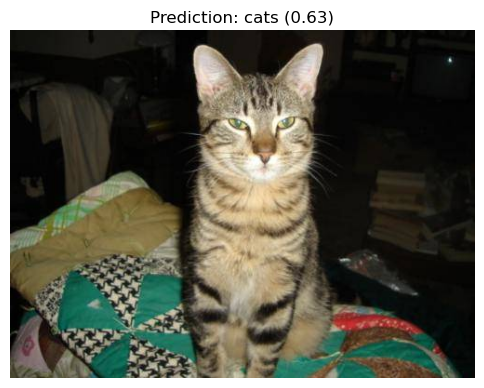

[{'label': 'cats', 'score': 0.6347697377204895},
 {'label': 'dogs', 'score': 0.3652302920818329}]

In [13]:
# Perform inference on a single test image
image_path = DATA_DIR + "/test/cats/cat.1070.jpg"
predict_image(image_path)

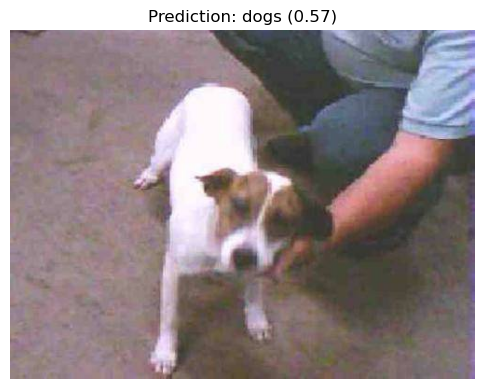

[{'label': 'dogs', 'score': 0.5707501173019409},
 {'label': 'cats', 'score': 0.42924991250038147}]

In [14]:
# TODO: Perform inference on this image using predict_image()
image_path = DATA_DIR + "/test/dogs/dog.1233.jpg"
==> YOUR CODE HERE

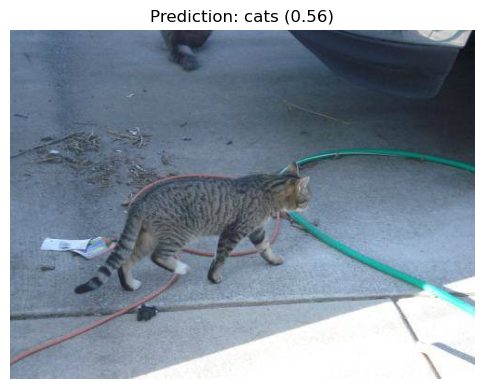

[{'label': 'cats', 'score': 0.5644586086273193},
 {'label': 'dogs', 'score': 0.4355413615703583}]

In [15]:
# TODO: Perform inference on this test image using predict_image()
image_path = DATA_DIR + "/test/cats/cat.1080.jpg"
==> YOUR CODE HERE

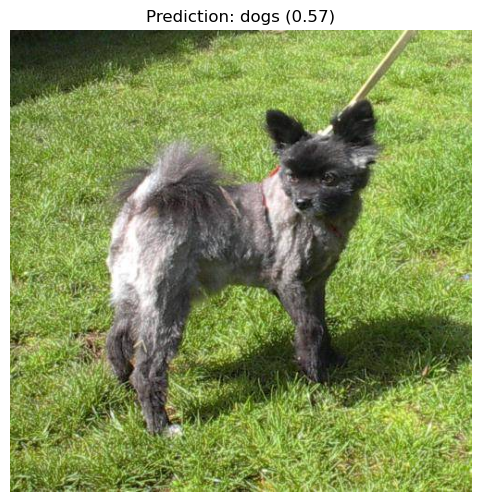

[{'label': 'dogs', 'score': 0.5674573183059692},
 {'label': 'cats', 'score': 0.43254271149635315}]

In [16]:
# TODO: Performance inference on this test image: dog.1132.jpg
==> YOUR CODE HERE